# Na poczatek



1.  Architektura BERT:

  - Dwukierunkowość: Analizuje cały tekst jednocześnie, a nie słowo po słowie. Doskonale rozumie szerszy kontekst.
  
  - Brak warstw rekurencyjnych: Opiera się wyłącznie na blokach Enkodera z architektury Transformer.
  
  - Mechanizm Self-Attention: Oblicza matematyczną zależność każdego słowa od wszystkich innych w zdaniu, używając macierzy zapytań ($Q$), kluczy ($K$) i wartości ($V$):$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

2. Model bazowy:

  - Zasada działania: Przetwarza dane tekstowe w sposób sekwencyjny.
  
  - Pamięć krótkotrwała i długotrwała: Wykorzystuje system bramek (np. bramka zapominania $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$) do kontrolowania przepływu informacji.
  
  - Ograniczenia: Utrata kontekstu przy bardzo długich sekwencjach tekstu i wolniejszy czas równoległego przetwarzania w porównaniu do BERT-a.

3. Czym jest Fine-tuning?

  - Pretrening (Wiedza ogólna): BERT uczy się reguł języka na gigantycznych zbiorach danych (np. Wikipedia) bez nadzoru.
  
  - Fine-tuning (Specjalizacja):
  
    Odcinamy pierwotną warstwę wyjściową modelu.
    
    Dodajemy nową "głowę klasyfikacyjną" dla naszego zbioru klas (np. pozytywny/negatywny).

    Trenujemy sieć na naszym zbiorze danych, minimalizując błąd entropii krzyżowej:
    $$\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$
    
4. Optymalizacja Treningu

  - Pełny Fine-tuning: Aktualizacja wszystkich wag w sieci. Wymaga ogromnej mocy obliczeniowej.
  
  - Zamrażanie (Freezing): Blokowanie aktualizacji gradientów (wartości wag) dla początkowych warstw BERT-a. Trenujemy tylko ostatnie warstwy i głowę klasyfikacyjną.
  
  - Learning Rate ($\alpha$): Kluczowy hiperparametr decydujący o wielkości kroku podczas aktualizacji wag. Zbyt duży zniszczy wiedzę pretrenowaną, zbyt mały wydłuży uczenie w nieskończoność.
  
5. Analiza Kompromisu

  - Wysokie zasoby: Pełne odmrożenie modelu daje najwyższą skuteczność (Accuracy), ale maksymalizuje czas epoki i zużycie pamięci VRAM.
  
  - Oszczędność zasobów: Zamrożenie $N$ dolnych warstw drastycznie obniża czas treningu.
  
  - Wniosek projektowy: Poszukiwanie "złotego środka", w którym spadek dokładności klasyfikacji jest marginalny, a zysk wydajnościowy znaczący.



In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


# Pierwsze kroki - przygotowanie danych

In [ ]:
!pip install torch torchvision torchaudio
!pip install transformers datasets

In [ ]:
# instalowanie paczek
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import DistilBertTokenizer

# Zbiór danych [IMDB](https://huggingface.co/datasets/stanfordnlp/imdb)
prosty zbiór 50 tysięcy recenzji i komentarzy sklasyfikowanych jednoznacznie (zerojedynkowo) jako pozytywne lub negatywne.

Istnieje dodatkowe 50 tysięcy komentarzy przeznaczone do nauczania bez nadzoru, które nie zostały tutaj wykorzystane.

In [ ]:
# zbiór to IMDB, czyli zbiór recenzji filmów (25k do treningu, 25k do testów)
dataset = load_dataset("imdb")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
tokenizer.tokenize(dataset["train"][0]["text"])


{'input_ids': [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036, 2657, 2008, 2012, 2034, 2009, 2001, 8243, 2011, 1057, 1012, 1055, 1012, 8205, 2065, 2009, 2412, 2699, 2000, 4607, 2023, 2406, 1010, 3568, 2108, 1037, 5470, 1997, 3152, 2641, 1000, 6801, 1000, 1045, 2428, 2018, 2000, 2156, 2023, 2005, 2870, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1996, 5436, 2003, 8857, 2105, 1037, 2402, 4467, 3689, 3076, 2315, 14229, 2040, 4122, 2000, 4553, 2673, 2016, 2064, 2055, 2166, 1012, 1999, 3327, 2016, 4122, 2000, 3579, 2014, 3086, 2015, 2000, 2437, 2070, 4066, 1997, 4516, 2006, 2054, 1996, 2779, 25430, 14728, 2245, 2055, 3056, 2576, 3314, 2107, 2004, 1996, 5148, 2162, 1998, 2679, 3314, 1999, 1996, 2142, 2163, 1012, 1999, 2090, 4851, 8801, 1998, 6623, 7939, 4697, 3619, 1997, 8947, 2055, 2037, 10740, 2006, 4331, 1010, 2016, 2038, 3348, 2007, 2014, 3689, 383

In [ ]:

# mapowanie
tokenized_datasets = dataset.map(
    lambda x: tokenizer( # funkcja anonimowa
        x["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    ),
    batched=True
)


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# formatowanie
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

In [ ]:
# dataloadery
batch_size = 16
train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(tokenized_datasets["test"], batch_size=batch_size)


In [ ]:
batch = next(iter(train_dataloader))
for k, v in batch.items():
    print(f"{k}: {v.shape}")

labels: torch.Size([16])
input_ids: torch.Size([16, 256])
attention_mask: torch.Size([16, 256])


### KOMENTARZ PROWADZACEGO


Bardzo mi się podoba użycie tutaj klasy torch.nn.Module.
Taką samę klasę trzeba będzie zrobić dla DistilBert'a - to znaczy coś w stylu

```
class TextClassifier(nn.Module):
    """
    Pretrenowany DistilBERT (zamrożony) + własna głowica klasyfikacyjna.
    Trenujemy TYLKO głowicę / całość - to może być parametr podwany w __init__.
    """

    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__(freeze: str)

        # --- backbone: zamrożony DistilBERT ---
        self.backbone = DistilBertModel.from_pretrained("distilbert-base-uncased")
        
        # tutaj decyzja co zamrażamy i to zamrażamy
        for param in self.backbone.parameters():
            param.requires_grad = False  # zamrażamy wagi

        hidden_size = self.backbone.config.hidden_size  # 768

        # --- własna głowica (to trenujemy) ---
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

         # self.head = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # DistilBERT zwraca last_hidden_state: (batch, seq_len, 768)
        with torch.no_grad():  # dodatkowe zabezpieczenie — nie liczymy gradientów
            outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        # Bierzemy embedding tokena [CLS] jako reprezentację całego tekstu
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

        return self.head(cls_embedding)  # (batch, num_classes)
  ```

  Potem należałoby stworzyć kod, który będzie trenował zadaną sieć na pobranych danych. Na sam koniec dodać kod, który sprawdzi jakość przetrenowanej sieci.

# Budowa Baseline'u
## Klasyfikator LSTM

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, output_dim=2, n_layers=1):
        super().__init__()

        # 1. Macierz Embeddingu
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # 2. Komórka LSTM
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            batch_first=True)

        # 3. Warstwa w pełni połączona (Klasyfikator)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids, attention_mask=None):

        # Osadzenie
        embedded = self.embedding(input_ids)

        # Przetworzenie sekwencji
        output, (hidden, cell) = self.lstm(embedded)

        # Klasyfikacja
        logits = self.fc(hidden[-1])

        return logits

In [ ]:

# Inicjalizacja modelu
vocab_size = tokenizer.vocab_size
model_baseline = LSTMClassifier(vocab_size=vocab_size)

In [ ]:
print(model_baseline)

LSTMClassifier(
  (embedding): Embedding(30522, 128)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
import torch.optim as optim
from tqdm.auto import tqdm

# Automatyczne wykrywanie urządzenia obliczeniowego (Karta Graficzna M-series w Macu, CUDA w RTX, lub zwykły CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Będziemy trenować na urządzeniu: {device}")

def train_model(model, train_dataloader, epochs=3, learning_rate=5e-5):
    # 1. Przerzucenie modelu na odpowiednie urządzenie
    model = model.to(device)

    # 2. Definicja funkcji kosztu i optymalizatora
    criterion = nn.CrossEntropyLoss()

    # Optymalizujemy TYLKO te wagi, które mają włączone obliczanie gradientu
    # (Dzięki temu zamrożony DistilBERT nie będzie ruszany)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    # 3. Główna pętla po epokach
    for epoch in range(epochs):
        model.train() # Przełączenie modelu w tryb treningowy (włącza m.in. Dropout)
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        # Pasek postępu dla batchy
        progress_bar = tqdm(train_dataloader, desc=f"Epoka {epoch+1}/{epochs}")

        for batch in progress_bar:
            # Rozpakowanie batcha i przerzucenie tensorów na GPU/CPU
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Krok 1: Wyzerowanie starych gradientów
            optimizer.zero_grad()

            # Krok 2: Forward pass (przepuszczenie danych przez model)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Krok 3: Obliczenie błędu
            loss = criterion(outputs, labels)

            # Krok 4: Backward pass (wyliczenie nowych gradientów)
            loss.backward()

            # Krok 5: Aktualizacja wag
            optimizer.step()

            # Zbieranie statystyk do wyświetlania
            total_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

            # Aktualizacja paska postępu o obecny loss i dokładność
            current_accuracy = correct_predictions / total_samples
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{current_accuracy:.4f}"})

        avg_loss = total_loss / len(train_dataloader)
        print(f"Koniec epoki {epoch+1} | Średni Loss: {avg_loss:.4f} | Dokładność (Train): {current_accuracy:.4f}")

    return model

Będziemy trenować na urządzeniu: cuda


In [ ]:
import time

print("--- ROZPOCZYNAMY TRENOWANIE BASELINE'U (LSTM) ---")
start_time = time.time()

# 1. Odpalamy naszą pętlę uczącą dla LSTM
# Ustawiamy 3 epoki - na start powinno wystarczyć, żeby model załapał wzorce
model_baseline = train_model(model_baseline, train_dataloader, epochs=3, learning_rate=1e-3)

end_time = time.time()
training_time = end_time - start_time
print(f"Trening LSTM zakończony w {training_time:.2f} sekund.")

# 2. Ewaluacja na zbiorze testowym (szukanie naszego bazowego Accuracy)
print("\n--- EWALUACJA NA ZBIORZE TESTOWYM ---")
model_baseline.eval() # Wyłączamy Dropout i inne mechanizmy treningowe
correct = 0
total = 0

# Wyłączamy liczenie gradientów (oszczędność pamięci i czasu)
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device) # LSTM tego nie używa, ale przekazujemy dla spójności
        labels = batch['labels'].to(device)

        # Predykcja
        outputs = model_baseline(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

baseline_accuracy = correct / total
print(f"Ostateczna dokładność (Accuracy) modelu bazowego (LSTM): {baseline_accuracy * 100:.2f}%")

--- ROZPOCZYNAMY TRENOWANIE BASELINE'U (LSTM) ---


Epoka 1/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Koniec epoki 1 | Średni Loss: 0.6940 | Dokładność (Train): 0.5086


Epoka 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Koniec epoki 2 | Średni Loss: 0.6904 | Dokładność (Train): 0.5214


Epoka 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Koniec epoki 3 | Średni Loss: 0.5165 | Dokładność (Train): 0.7311
Trening LSTM zakończony w 69.74 sekund.

--- EWALUACJA NA ZBIORZE TESTOWYM ---
Ostateczna dokładność (Accuracy) modelu bazowego (LSTM): 82.66%


## Klasyfikator na podstawie DistilBERT


W budowie klasyfikatora na podstawie transformera [DistilBERT](https://huggingface.co/docs/transformers/model_doc/distilbert) został(a) użyty(a):
- [tokenizator DistilBERT]() bez własnych zmian
- optymalizator [ADAM](https://huggingface.co/docs/bitsandbytes/reference/optim/adam)
- głowa o architekturze w kolejności:
    - warstwa liniowa o rozmiarze 768 -> 256
    - [ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
    - warstwa dropout o współczynniku `0.3`
    - warstwa liniowa o rozmiarze 256 -> 2
    
trenowana z funkcją straty [cross entropy loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) wydającą się dobrą do zadań klasyfikacyjnych z N klasami (tu dwie).

Wszystkie parametry DistilBERTa zostały na czas treningu zamrożone.

In [ ]:
import copy
# type hinty
from typing import Callable

import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

import transformers
from transformers import DistilBertModel, DistilBertTokenizer
import tokenizers

from datasets import load_dataset
from tqdm.notebook import tqdm

assert torch.cuda.is_available(), "Nie ma CUDA (karty graficznej)"

class Klasyfikator(nn.Module):
    """ """
    def __init__(self, frozen_model: nn.Module, head: nn.Module | nn.Sequential, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # fields
        self.head = head
        self.frozen_model = frozen_model

        return

    # konstruktor
    @classmethod
    def new(cls,
            frozen_model: transformers.BertModel
                        | transformers.DistilBertModel
                        | nn.Module,
            head: Callable[[int], nn.Module | nn.Sequential],
            *args,
            **kwargs):
        """
        taki konstruktor
        head powininen być lambdą która bierze hidden size modelu i wciska go w rozmiar pierwszej warstwy głowy
        """

        self = cls(frozen_model, head(frozen_model.config.hidden_size),  *args, **kwargs)
        return self

    def forward(self, *args, **kwargs):
        embedding = self.frozen_model(*args, **kwargs)
        ret = self.head(embedding.last_hidden_state[:, 0, :])
        return ret

    #######################################################

def wytrenuj(model, liczba_epok: int, dataloader, funkcja_straty, optimizer):
    print("Rozpoczynamy trening")
    start_time = time.time()
    for epoka in range(liczba_epok):
        loss_total = 0


        for batch in tqdm(dataloader):
            batch = {k: v.to("cuda") for k, v in batch.items()}
            outputs = model(
                input_ids = batch["input_ids"],
                attention_mask = batch["attention_mask"]
            )
            loss = funkcja_straty(outputs, batch["labels"].long())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_total += loss.item()

        print(f"Epoka {epoka + 1} | Loss: {loss_total:.4f} | Średnia: {loss_total / len(dataloader)}")
    end_time = time.time()
    return model, (start_time - end_time)

def stworz_model(frozen_model):
    model = Klasyfikator.new(
        frozen_model = frozen_model,
        head = lambda hidden_size: nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
        ),
    ) # /model

    model.to("cuda")
    model.train()

    model_3 = copy.deepcopy(model)
    model_3, czas_3 = wytrenuj(
        model_3,
        3,
        train_dataloader,
        nn.CrossEntropyLoss(),
        optim.Adam(model_3.parameters(), lr=2e-5)
    )

    print("Zapisuję 3 epokowy")
    torch.save(model_3, f"./distilbert_custom_head_{str(3)}_epok.pt")

    model_6 = copy.deepcopy(model)
    model_6, czas_6 = wytrenuj(
        model_6,
        6,
        train_dataloader,
        nn.CrossEntropyLoss(),
        optim.Adam(model_6.parameters(), lr=2e-5)
    )

    print("Zapisuję 6 epokowy")
    torch.save(model_6, f"./distilbert_custom_head_{str(6)}_epok.pt")

    model_9 = copy.deepcopy(model)
    model_9, czas_9 = wytrenuj(
        model_9,
        9,
        train_dataloader,
        nn.CrossEntropyLoss(),
        optim.Adam(model_9.parameters(), lr=2e-5)
    )

    print("Zapisuję 9 epokowy")
    torch.save(model_9, f"./distilbert_custom_head_{str(9)}_epok.pt")
    return tuple([model_3, model_6, model_9]), tuple([czas_3, czas_6, czas_9])

def main():
  frozen_model_1 = DistilBertModel.from_pretrained("distilbert-base-uncased")
  for param in frozen_model_1.parameters():
     param.requires_grad = False

  modele_cale, czasy_cale = stworz_model(frozen_model_1)

  frozen_model_2 = DistilBertModel.from_pretrained("distilbert-base-uncased")
  for param in frozen_model_2.parameters():
      param.requires_grad = False # zmienic na inne zamrozone warstwy

  for param in frozen_model_2.transformer.layer[-1].parameters():
    param.requires_grad = True

  modele_wybrane, czasy_wybrane = stworz_model(frozen_model_2)

  return modele_cale, czasy_cale, modele_wybrane, czasy_wybrane

stuff = main()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Rozpoczynamy trening


  0%|          | 0/1563 [00:00<?, ?it/s]

Epoka 1 | Loss: 917.4573 | Średnia: 0.586984841738156


...

Epoka 2 | Loss: 706.9979 | Średnia: 0.45233392556241436


  0%|          | 0/1563 [00:00<?, ?it/s]

Epoka 3 | Loss: 646.0887 | Średnia: 0.4133645067002174
Zapisuję 3 epokowy
Rozpoczynamy trening


  0%|          | 0/1563 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
model_3_cale = torch.load("/content/distilbert_custom_head_3_epok.pt", weights_only=False)

In [ ]:
text_to_predict = "I kinda like it, nut it was too long. I like the main actor a lot!"

# Tokenize the input text
inputs = tokenizer(text_to_predict, return_tensors="pt", padding=True, truncation=True, max_length=256)

# Move inputs to the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_ids = inputs["input_ids"].to(device)
attention_mask = inputs["attention_mask"].to(device)

# Set the model to evaluation mode and move to device
model_3_cale.eval()
model_3_cale.to(device)

# Make a prediction
with torch.no_grad():
    outputs = model_3_cale(input_ids=input_ids, attention_mask=attention_mask)

# Get the predicted class (0 or 1)
predicted_class_id = torch.argmax(outputs, dim=1).item()

# Interpret the prediction
# Assuming 0 is negative and 1 is positive based on IMDB dataset labels.
# The IMDB dataset maps label 0 to negative and label 1 to positive.
sentiment = "Positive" if predicted_class_id == 1 else "Negative"

print(f"Text: \"{text_to_predict}\"")
print(f"Predicted sentiment: {sentiment} (Label: {predicted_class_id})")

Text: "I kinda like it, nut it was too long. I like the main actor a lot!"
Predicted sentiment: Positive (Label: 1)


In [ ]:
inputs

{'input_ids': tensor([[  101,  1045, 17704,  2066,  2009,  1037,  2843,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}

# Testowanie klasyfikatora na podstawie DistilBERT

In [ ]:
def test(model, dataloader):
  model.to("cuda")
  model.eval()

  correct = 0
  total = 0

  with torch.no_grad():
      for batch in dataloader:
          batch = {k: v.to("cuda") for k, v in batch.items()}

          outputs = model(
              input_ids=batch["input_ids"],
              attention_mask=batch["attention_mask"]
          )

          pred = torch.argmax(outputs, dim=1)

          total += batch["labels"].size(0)
          correct += (pred == batch["labels"]).sum().item()

  accuracy = correct / total
  return accuracy

model_3_cale, model_6_cale, model_9_cale = stuff[0]

test_3_cale = test(model_3_cale, test_dataloader)
test_6_cale = test(model_6_cale, test_dataloader)
test_9_cale = test(model_9_cale, test_dataloader)

model_3_wybrane, model_6_wybrane, model_9_wybrane,  = stuff[2]

test_3_wybrane = test(model_3_wybrane, test_dataloader)
test_6_wybrane = test(model_6_wybrane, test_dataloader)
test_9_wybrane = test(model_9_wybrane, test_dataloader)


NameError: name 'stuff' is not defined

In [ ]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.9 MB/s  0:00:01a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 6.8 MB/s  0:00:006.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.4 MB/s  0:00:00m 6.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


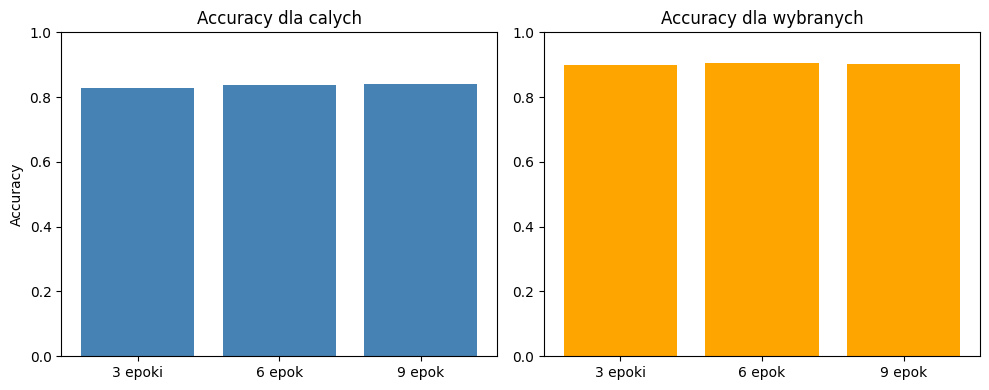

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


acc_cale= [test_3_cale, test_6_cale, test_9_cale]
acc_wybrane = [test_3_wybrane, test_6_wybrane, test_9_wybrane]

labels_cale = ['3 epoki', '6 epok', '9 epok']
labels_wybrane = ['3 epoki', '6 epok', '9 epok']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels_cale, acc_cale, color='steelblue')
axes[0].set_title("Accuracy dla calych")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")


axes[1].bar(labels_wybrane, acc_wybrane, color='orange')
axes[1].set_title("Accuracy dla wybranych")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Wyniki accuracy
Z wykresów wynika, że liczba epok nie miała dużego wpływu na dokładnosc predykcji naszego klasyfikatora na podstawie DistilBERT już dla tak małej liczby jak 3 epoki. Wartość jest stała i niezależna od liczby epok zarówno dla modelu z zamrożonymi wszystkimi parametrami poza głową jak i dla modelu z zamrożonymi wszystkimi warstwami oprócz ostatniej i głowy. Dokładność modelu zamrożonego całkowicie jest porównywalna z modelem LSTM, natomiast dokładność modelu z odmrożoną ostatnią warstwą jest większa o ~10 punktów procentowych.

Należy pamiętać, że wybrane przez zespół zadanie klasyfikacyjne jest proste pod względem inżynieryjno-matematycznym ale również jest zadaniem szczególnego przeznaczenia, tj. jest zadaniem będącym małym wycinkiem ze wszystkich zadań do których przeznaczona jest architektura transformera (czyli architektura DistilBERT), co może oznaczać zawyżenie współczynnika dokładności w obu przypadkach w porównaniu ze wspólczynnikiem dokładności w rzeczywistych zadaniach klasyfikacyjnych.

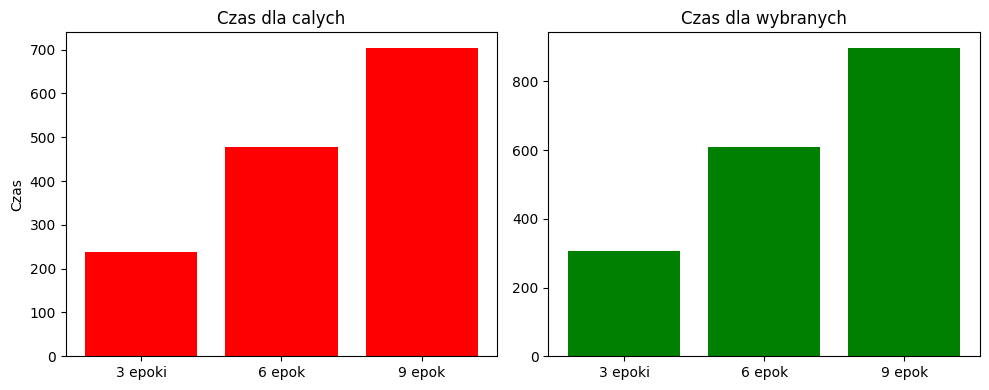

In [ ]:
czas_cale = list(map(abs, stuff[1]))
czas_wybrane = list(map(abs, stuff[3]))

labels_cale = ['3 epoki', '6 epok', '9 epok']
labels_wybrane = ['3 epoki', '6 epok', '9 epok']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels_cale, czas_cale, color='red')
axes[0].set_title("Czas dla calych")
axes[0].set_ylabel("Czas")


axes[1].bar(labels_wybrane, czas_wybrane, color='green')
axes[1].set_title("Czas dla wybranych")

plt.tight_layout()
plt.show()

# Wyniki czasowe
Z pomiaru czasu trenowania modelu z zamrożonymi wszystkimi warstwami odnotowano trzykrotnie większy czas trenowania przez 9 epok niż przez 3 epoki z równoczesym niemal zerowym wzrostem dokładności w porównaniu z trenowaniem przez mniejszą liczbę epok. Takie same obserwacje zostały odnotowane w przypadku modelu z odmrożoną ostatnią warstwą transformera.

Godny uwagi jest fakt, że czas trenowania sieci LSTM jest prawie czterokrotnie krótszy w porównaniu do czasu trenowania modelu DistilBERT z odmrożoną jedynie głową przy podobnym wskaźniku dokładności; również jest tak w przypadku modelu z odmrożoną ostatnią warstwą transformera ale z zachowaniem mniejszej dokładności o ~10 punktów procentowych.



# Wnioski

Jeżeli ważna jest maksymalizacja współczynnika dokładności, lepszym modelem klasyfikacyjnym jest model DistilBERT trenowany krótko i z odmrożonymi końcowymi warstwami.

Jeżeli ważny jest krótki czas treningu dużej liczby modeli dostosowanych do prostych zadań klasyfikacyjnych, lepszym modelem klasyfikacyjnym może okazać się model LSTM.